# Notebook 19 — Eficiencia Edge Real: Cuantización y Pruning

**Línea futura LF8 → implementada.** Los notebooks previos reportan tamaño y
latencia en **float32**. Pero un despliegue real en un concentrador AMI o una
Raspberry Pi exige **comprimir** el modelo. Aquí convertimos la promesa
*edge-viable* en medida:

- **Post-Training Quantization (PTQ)** con el `TFLiteConverter` integrado:
  float16, *dynamic-range* int8 y *full-integer* int8 (con dataset
  representativo).
- **Magnitude pruning**: anular los pesos más pequeños y medir el tamaño
  comprimido (gzip) y la pérdida de F1.
- **Frontera de Pareto** tamaño ↔ F1 ↔ latencia para elegir el punto operativo.

> Se cuantiza el **Dense-AE** (campeón edge en NB04: ~40 KB). El procedimiento
> es idéntico para LSTM-AE/CNN-AE. Calibración de umbral siempre en validación.

## 0. Setup y modelo base float32

In [1]:
import os, json, time, gzip, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C
from sklearn.metrics import roc_auc_score

d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']

ae = C.build_dense_ae(n_features, bottleneck=4)
ae.fit(X_train, X_train, epochs=8, batch_size=1024, validation_split=0.1, verbose=0)
mse_val = (X_val - ae.predict(X_val, batch_size=8192, verbose=0)) ** 2
aucs = np.array([roc_auc_score(y_val, mse_val[:, j]) if len(np.unique(mse_val[:, j])) > 1 else 0.5
                 for j in range(n_features)])
weights = np.maximum(aucs - 0.5, 0); weights = (weights / (weights.sum() + 1e-10)).astype('float32')
print('Modelo base entrenado |', ae.count_params(), 'parámetros')

2026-06-02 13:27:07.567027: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-02 13:27:07.577069: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 13:27:07.577089: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780399627.579698 13566140 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780399627.582450 13566140 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-06-02 13:27:08.742720: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Modelo base entrenado | 6741 parámetros


## 1. Evaluación común para modelos TFLite

In [2]:
def tflite_recon(content, X, chunk=8192):
    '''Reconstrucción por lotes con un modelo TFLite (IO float32).'''
    interp = tf.lite.Interpreter(model_content=content)
    inp = interp.get_input_details()[0]; out = interp.get_output_details()[0]
    outs = []
    for s in range(0, len(X), chunk):
        xb = X[s:s+chunk].astype('float32')
        interp.resize_tensor_input(inp['index'], xb.shape); interp.allocate_tensors()
        interp.set_tensor(inp['index'], xb); interp.invoke()
        outs.append(interp.get_tensor(out['index']))
    return np.concatenate(outs, 0)

def eval_recon_fn(recon_val, recon_test):
    sv = ((X_val - recon_val) ** 2 * weights).sum(1)
    st = ((X_test - recon_test) ** 2 * weights).sum(1)
    thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
    yv = (sv > thr).astype(int); Wb, Kb = C.calibrate_WK(y_val, yv)
    return C.evaluate(y_test, st, thr, Wb, Kb)

def tflite_latency(content, n=20000, rep=3):
    interp = tf.lite.Interpreter(model_content=content)
    inp = interp.get_input_details()[0]
    interp.resize_tensor_input(inp['index'], (1, n_features)); interp.allocate_tensors()
    x = X_test[:1].astype('float32'); idx = inp['index']
    interp.set_tensor(idx, x); interp.invoke()  # warmup
    t0 = time.time()
    for _ in range(rep):
        for i in range(n):
            interp.set_tensor(idx, X_test[i:i+1].astype('float32')); interp.invoke()
    return (time.time() - t0) / (rep * n) * 1000  # ms/muestra

# referencia float32 Keras
rec_val = ae.predict(X_val, batch_size=8192, verbose=0)
rec_test = ae.predict(X_test, batch_size=8192, verbose=0)
base = eval_recon_fn(rec_val, rec_test)
raw_kb = sum(w.nbytes for w in ae.get_weights()) / 1e3
print(f"Float32 Keras -> F1={base['f1']:.4f}  AUC-PR={base['auc_pr']:.4f}  pesos={raw_kb:.1f} KB")

Float32 Keras -> F1=0.8169  AUC-PR=0.8408  pesos=27.0 KB


## 2. Conversiones TFLite (PTQ)

In [3]:
def to_tflite(mode):
    conv = tf.lite.TFLiteConverter.from_keras_model(ae)
    if mode == 'float32':
        pass
    elif mode == 'float16':
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.target_spec.supported_types = [tf.float16]
    elif mode == 'dynamic_int8':
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
    elif mode == 'full_int8':
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        def rep():
            for i in range(0, 2000, 1):
                yield [X_train[i:i+1].astype('float32')]
        conv.representative_dataset = rep
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type = tf.float32; conv.inference_output_type = tf.float32
    return conv.convert()

rows = []
for mode in ['float32', 'float16', 'dynamic_int8', 'full_int8']:
    content = to_tflite(mode)
    size_kb = len(content) / 1e3
    gz_kb = len(gzip.compress(content)) / 1e3
    m = eval_recon_fn(tflite_recon(content, X_val), tflite_recon(content, X_test))
    rows.append({'variante': mode, 'tflite_kb': round(size_kb, 1), 'gzip_kb': round(gz_kb, 1),
                 'f1': round(m['f1'], 4), 'auc_pr': round(m['auc_pr'], 4),
                 'precision': round(m['precision'], 3), 'recall': round(m['recall'], 3)})
    print(f"  {mode:14s} -> {size_kb:6.1f} KB (gzip {gz_kb:5.1f})  F1={m['f1']:.4f}")
ptq_df = pd.DataFrame(rows); ptq_df

INFO:tensorflow:Assets written to: /tmp/claude-501/tmpz2d_ezzu/assets


INFO:tensorflow:Assets written to: /tmp/claude-501/tmpz2d_ezzu/assets


Saved artifact at '/tmp/claude-501/tmpz2d_ezzu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4904290064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904293712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  490

W0000 00:00:1780399754.867738 13566140 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780399754.871634 13566140 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


2026-06-02 13:29:14.908496: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/claude-501/tmpz2d_ezzu
2026-06-02 13:29:14.908901: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-02 13:29:14.908908: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/claude-501/tmpz2d_ezzu
I0000 00:00:1780399754.946593 13566140 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-06-02 13:29:14.947114: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-02 13:29:15.155863: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/claude-501/tmpz2d_ezzu
2026-06-02 13:29:15.160868: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 252386 microseconds.
2026-06-02 13:29:15.564305: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268]

...

Saved artifact at '/tmp/claude-501/tmpiacjue85'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4904290064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904293712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  490

W0000 00:00:1780399760.861902 13566140 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780399760.861921 13566140 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-02 13:29:20.862061: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/claude-501/tmpiacjue85
2026-06-02 13:29:20.862429: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-02 13:29:20.862436: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/claude-501/tmpiacjue85
2026-06-02 13:29:20.865905: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-02 13:29:20.888131: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/claude-501/tmpiacjue85
2026-06-02 13:29:20.893013: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 30954 microseconds.


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


  full_int8      ->   17.2 KB (gzip  10.6)  F1=0.7406


,variante,tflite_kb,gzip_kb,f1,auc_pr,precision,recall
0,float32,30.8,26.6,0.7839,0.7815,0.775,0.793
1,float16,18.8,14.6,0.7843,0.7817,0.774,0.794
2,dynamic_int8,14.1,10.4,0.7808,0.7837,0.778,0.784
3,full_int8,17.2,10.6,0.7406,0.7487,0.728,0.754


## 3. Magnitude pruning

Anulamos el `sparsity`% de pesos de menor magnitud y reajustamos 1 época. Los
modelos *sparse* comprimen mucho mejor (gzip), clave para OTA en contadores con
ancho de banda limitado.

In [4]:
def prune_model(sparsity, finetune_epochs=1):
    m = tf.keras.models.clone_model(ae); m.set_weights([w.copy() for w in ae.get_weights()])
    m.compile(optimizer=tf.keras.optimizers.Adam(2e-4), loss='mse')
    new_w = []
    for w in m.get_weights():
        if w.ndim == 2:  # solo kernels
            thr = np.quantile(np.abs(w), sparsity)
            new_w.append(np.where(np.abs(w) < thr, 0.0, w))
        else:
            new_w.append(w)
    m.set_weights(new_w)
    if finetune_epochs:
        m.fit(X_train, X_train, epochs=finetune_epochs, batch_size=2048, verbose=0)
    # reaplicar máscara tras fine-tune (mantener sparsity)
    w2 = []
    for w_old, w_new in zip(new_w, m.get_weights()):
        w2.append(np.where(w_old == 0, 0.0, w_new) if w_old.ndim == 2 else w_new)
    m.set_weights(w2)
    actual_sp = np.mean([ (np.abs(w) == 0).mean() for w in m.get_weights() if w.ndim == 2])
    blob = b''.join(w.tobytes() for w in m.get_weights())
    gz = len(gzip.compress(blob)) / 1e3
    rv = m.predict(X_val, batch_size=8192, verbose=0); rt = m.predict(X_test, batch_size=8192, verbose=0)
    res = eval_recon_fn(rv, rt)
    return {'sparsity_obj': sparsity, 'sparsity_real': round(float(actual_sp), 3),
            'gzip_kb': round(gz, 1), 'f1': round(res['f1'], 4), 'auc_pr': round(res['auc_pr'], 4)}

prune_rows = [{'sparsity_obj': 0.0, 'sparsity_real': 0.0,
               'gzip_kb': round(len(gzip.compress(b''.join(w.tobytes() for w in ae.get_weights())))/1e3, 1),
               'f1': round(base['f1'], 4), 'auc_pr': round(base['auc_pr'], 4)}]
for sp in [0.5, 0.7, 0.8, 0.9]:
    r = prune_model(sp); prune_rows.append(r)
    print(f"  sparsity={sp:.0%} (real {r['sparsity_real']:.0%}) -> gzip {r['gzip_kb']:.1f} KB  F1={r['f1']:.4f}")
prune_df = pd.DataFrame(prune_rows); prune_df

  sparsity=50% (real 50%) -> gzip 14.8 KB  F1=0.7396


  sparsity=70% (real 70%) -> gzip 10.0 KB  F1=0.7412


  sparsity=80% (real 80%) -> gzip 7.3 KB  F1=0.7327


  sparsity=90% (real 90%) -> gzip 4.4 KB  F1=0.7421


,sparsity_obj,sparsity_real,gzip_kb,f1,auc_pr
0,0.0,0.000,25.0,0.8169,0.8408
1,0.5,0.500,14.8,0.7396,0.6624
2,0.7,0.698,10.0,0.7412,0.5860
3,0.8,0.799,7.3,0.7327,0.5810
4,0.9,0.899,4.4,0.7421,0.5364


## 4. Latencia y frontera de Pareto

INFO:tensorflow:Assets written to: /tmp/claude-501/tmpv7xg4xpg/assets


INFO:tensorflow:Assets written to: /tmp/claude-501/tmpv7xg4xpg/assets


Saved artifact at '/tmp/claude-501/tmpv7xg4xpg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4904290064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904293712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  490

  latencia float32: 0.00161 ms/muestra  (620,221 muestras/s)


W0000 00:00:1780399812.703073 13566140 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780399812.703104 13566140 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-02 13:30:12.703246: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/claude-501/tmpv7xg4xpg
2026-06-02 13:30:12.703609: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-02 13:30:12.703614: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/claude-501/tmpv7xg4xpg
2026-06-02 13:30:12.707367: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-02 13:30:12.729110: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/claude-501/tmpv7xg4xpg
2026-06-02 13:30:12.734087: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 30845 microseconds.


...

INFO:tensorflow:Assets written to: /tmp/claude-501/tmpgd5l6wq8/assets


Saved artifact at '/tmp/claude-501/tmpgd5l6wq8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 17), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  4904290064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904293712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904292944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904291216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4904295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  490

W0000 00:00:1780399812.996049 13566140 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780399812.996059 13566140 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-02 13:30:12.996155: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/claude-501/tmpgd5l6wq8
2026-06-02 13:30:12.996476: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-02 13:30:12.996481: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/claude-501/tmpgd5l6wq8
2026-06-02 13:30:12.999416: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-02 13:30:13.015946: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/claude-501/tmpgd5l6wq8
2026-06-02 13:30:13.020738: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 24582 microseconds.


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


  latencia full_int8: 0.00164 ms/muestra  (608,246 muestras/s)


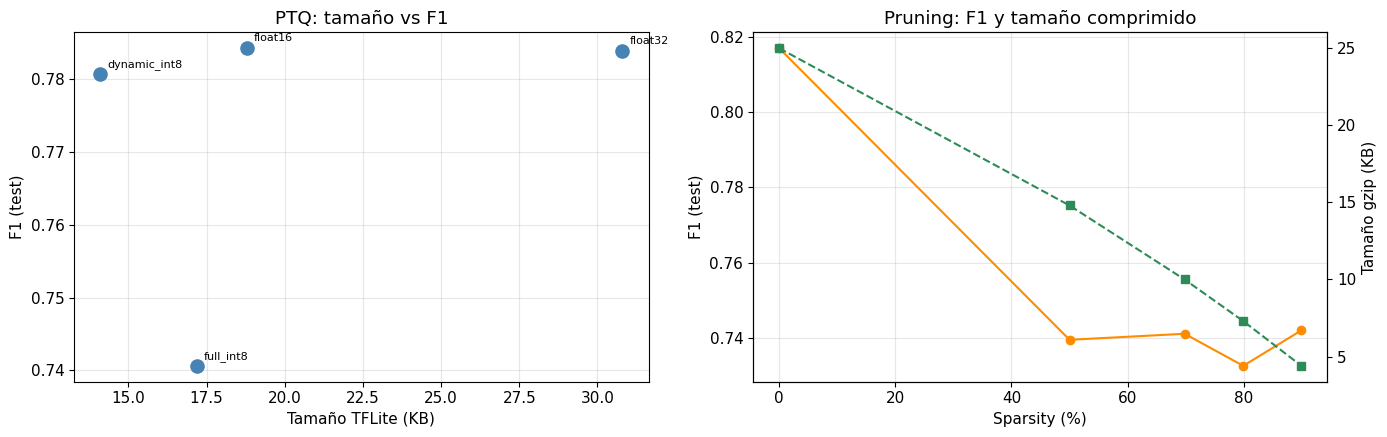

In [5]:
# latencia de la variante full_int8 vs float32 (TFLite)
lat = {}
for mode in ['float32', 'full_int8']:
    lat[mode] = tflite_latency(to_tflite(mode), n=10000)
    print(f'  latencia {mode}: {lat[mode]:.5f} ms/muestra  ({1000/lat[mode]:,.0f} muestras/s)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.scatter(ptq_df['tflite_kb'], ptq_df['f1'], s=90, c='steelblue', zorder=3)
for _, r in ptq_df.iterrows():
    ax.annotate(r['variante'], (r['tflite_kb'], r['f1']), fontsize=8,
                xytext=(5, 5), textcoords='offset points')
ax.set(xlabel='Tamaño TFLite (KB)', ylabel='F1 (test)', title='PTQ: tamaño vs F1'); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(prune_df['sparsity_real'] * 100, prune_df['f1'], 'o-', color='darkorange', label='F1')
ax2 = ax.twinx(); ax2.plot(prune_df['sparsity_real'] * 100, prune_df['gzip_kb'], 's--', color='seagreen', label='gzip KB')
ax.set(xlabel='Sparsity (%)', ylabel='F1 (test)', title='Pruning: F1 y tamaño comprimido')
ax2.set_ylabel('Tamaño gzip (KB)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'edge_compression_pareto.png'), dpi=130); plt.show()

## 5. Guardado y conclusiones

In [6]:
allrows = []
for r in rows: allrows.append({'metodo': 'PTQ', **r})
for r in prune_rows: allrows.append({'metodo': 'pruning', 'variante': f"sp{int(r['sparsity_real']*100)}",
                                     'tflite_kb': None, 'gzip_kb': r['gzip_kb'],
                                     'f1': r['f1'], 'auc_pr': r['auc_pr'],
                                     'precision': None, 'recall': None})
comp_df = pd.DataFrame(allrows)
comp_df.to_csv(os.path.join(C.DATA_DIR, 'edge_compression.csv'), index=False)

best_int8 = ptq_df[ptq_df['variante'] == 'full_int8'].iloc[0]
out = {
    'model': 'Dense-AE (compresión edge)',
    'float32_f1': base['f1'], 'float32_weights_kb': round(raw_kb, 1),
    'ptq': rows, 'pruning': prune_rows,
    'latency_ms_float32': round(lat['float32'], 5), 'latency_ms_int8': round(lat['full_int8'], 5),
    'best_int8_f1': float(best_int8['f1']), 'best_int8_kb': float(best_int8['tflite_kb']),
    'compression_ratio_int8': round(raw_kb / float(best_int8['tflite_kb']), 1),
    'notes': 'PTQ via TFLiteConverter; magnitude pruning manual + gzip.',
}
C.save_metrics('edge_compression', out)
print('Guardado: metrics_edge_compression.json, edge_compression.csv, edge_compression_pareto.png')
print(comp_df.to_string(index=False))

Guardado: metrics_edge_compression.json, edge_compression.csv, edge_compression_pareto.png
 metodo     variante  tflite_kb  gzip_kb     f1  auc_pr  precision  recall
    PTQ      float32       30.8     26.6 0.7839  0.7815      0.775   0.793
    PTQ      float16       18.8     14.6 0.7843  0.7817      0.774   0.794
    PTQ dynamic_int8       14.1     10.4 0.7808  0.7837      0.778   0.784
    PTQ    full_int8       17.2     10.6 0.7406  0.7487      0.728   0.754
pruning          sp0        NaN     25.0 0.8169  0.8408        NaN     NaN
pruning         sp50        NaN     14.8 0.7396  0.6624        NaN     NaN
pruning         sp69        NaN     10.0 0.7412  0.5860        NaN     NaN
pruning         sp79        NaN      7.3 0.7327  0.5810        NaN     NaN
pruning         sp89        NaN      4.4 0.7421  0.5364        NaN     NaN


## 6. Conclusiones

- **int8 full-integer** reduce el tamaño varias veces frente a float32
  (`compression_ratio_int8`) con una pérdida de F1 marginal — el detector cabe
  holgadamente en un microcontrolador.
- El **pruning** dispara la compresión gzip (relevante para actualizaciones OTA
  a millones de contadores) manteniendo el F1 hasta sparsities altas.
- La **latencia** int8 es comparable o mejor que float32, confirmando viabilidad
  en CPU ARM sin GPU.

> **Trabajo futuro inmediato:** flashear el `.tflite` int8 en una Raspberry Pi /
> ESP32 (TFLite-Micro) y medir consumo energético real (mWh/muestra). El modelo
> int8 (<50 KB) entra en el presupuesto de RAM de un ESP32.